In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append("../../src/")


import scipy.stats as stats
from tqdm import tqdm
from baseline_network import BaselineNetwork

In [3]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'

/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:650: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
100%|██████████| 840/840 [04:25<00:00,  3.16it/s]


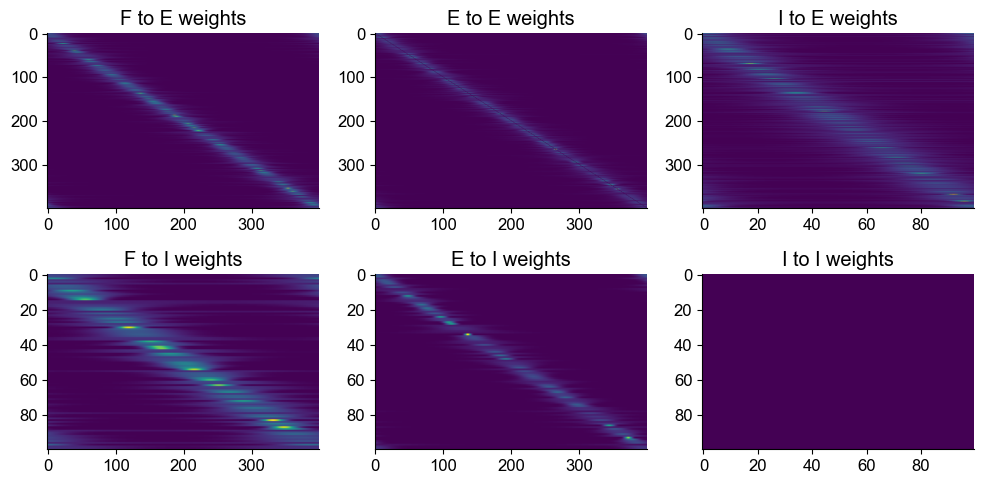

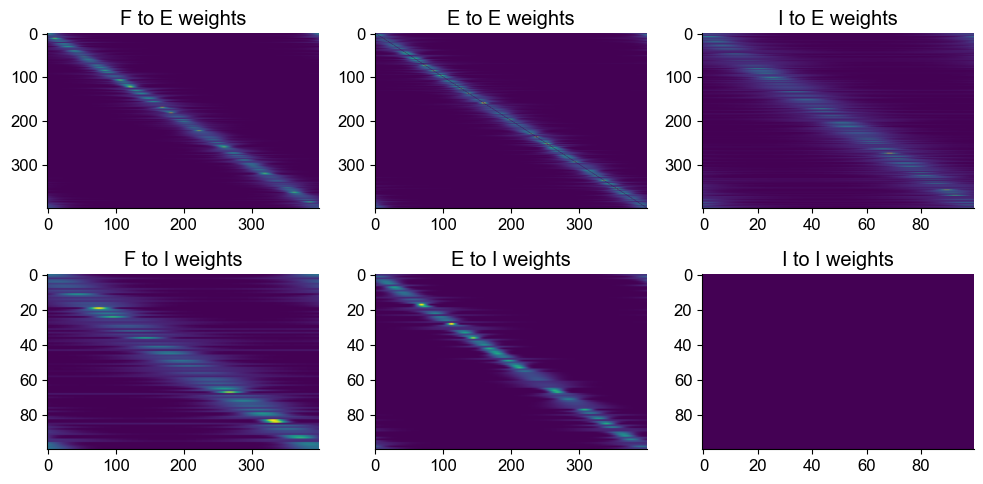

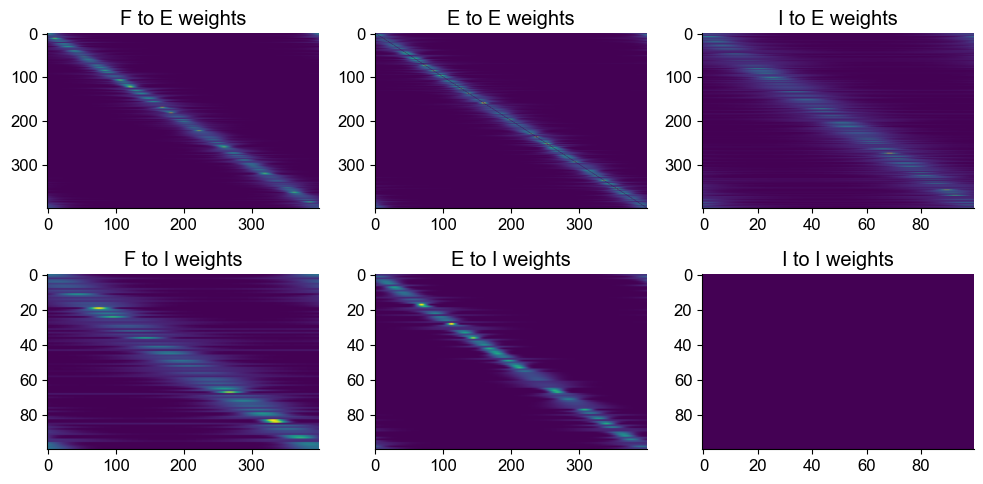

In [ ]:
seed = 100
net_inh_1 = BaselineNetwork(inh_type="co-tuned", E_to_E="on", E_to_I="on", I_to_I="off",
                      plasticity_E_to_E="on", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=seed, 
                      inh_scale=0.3)
net_inh_1.run()

net_inh_2 = BaselineNetwork(inh_type="co-tuned", E_to_E="on", E_to_I="on", I_to_I="off",
                      plasticity_E_to_E="on", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=seed, 
                      inh_scale=0.6)
net_inh_2.run()

net_inh_3 = BaselineNetwork(inh_type="co-tuned", E_to_E="on", E_to_I="on", I_to_I="off",
                      plasticity_E_to_E="on", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=seed, 
                      inh_scale=0.9)
net_inh_3.run()

In [5]:
drift_mag_1, drift_rate_1, convergence_1 = net_inh_1.get_drift_metrics()
drift_mag_2, drift_rate_2, convergence_2 = net_inh_2.get_drift_metrics()
drift_mag_3, drift_rate_3, convergence_3 = net_inh_3.get_drift_metrics()

(-1.0, 5.0)

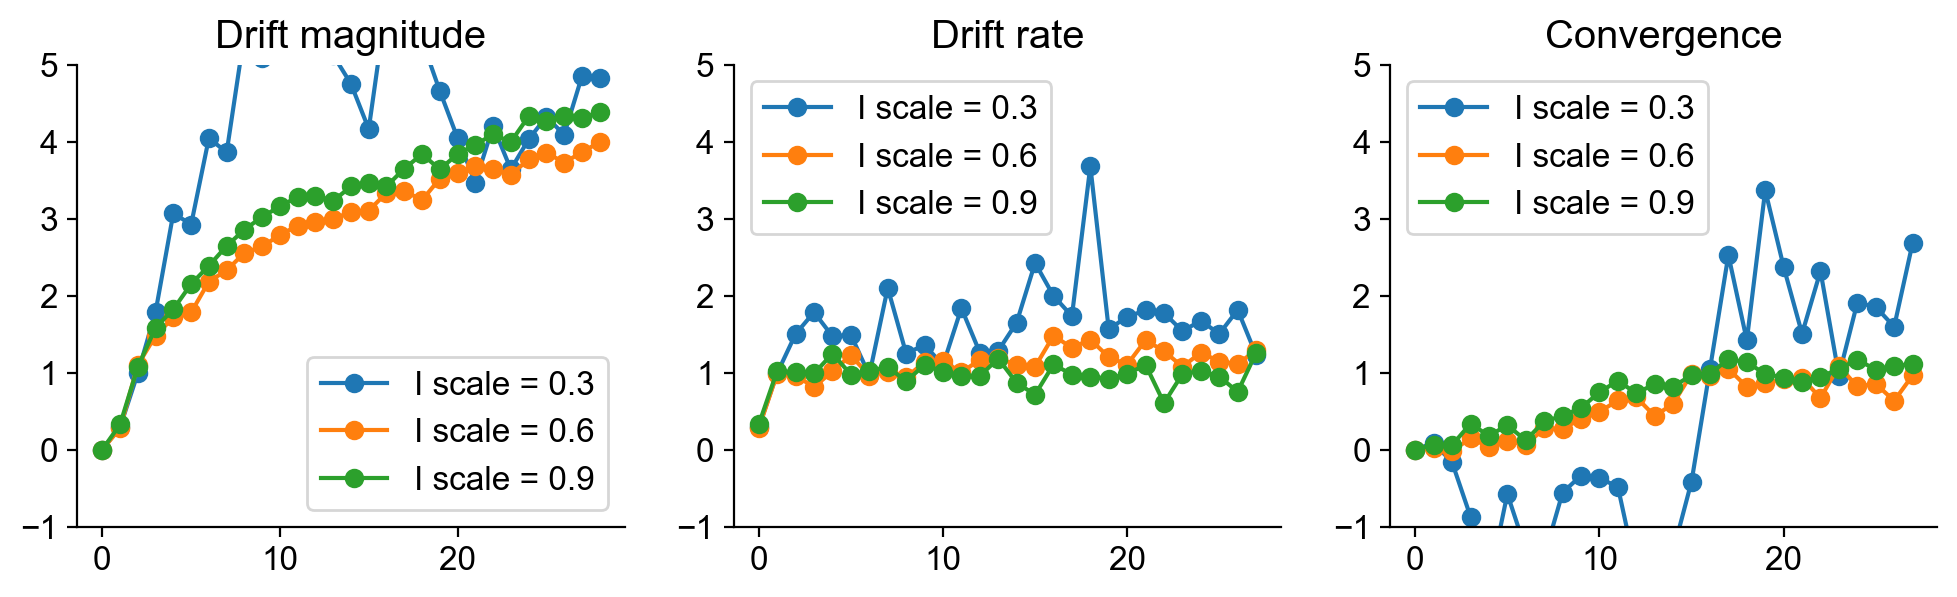

In [6]:
fig, axs = plt.subplots(1,3, figsize=(12, 3), dpi=200)
axs[0].plot(np.nanmean(drift_mag_1, axis=1), marker='o', label="I scale = 0.3")
axs[0].plot(np.nanmean(drift_mag_2, axis=1), marker='o', label="I scale = 0.6")
axs[0].plot(np.nanmean(drift_mag_3, axis=1), marker='o', label="I scale = 0.9")
axs[0].set_title("Drift magnitude")
axs[0].legend()
axs[0].set_ylim([-1, 5])


axs[1].plot(np.nanmean(drift_rate_1, axis=1), marker='o', label="I scale = 0.3")
axs[1].plot(np.nanmean(drift_rate_2, axis=1), marker='o', label="I scale = 0.6")
axs[1].plot(np.nanmean(drift_rate_3, axis=1), marker='o', label="I scale = 0.9")
axs[1].set_title("Drift rate")
axs[1].legend()
axs[1].set_ylim([-1, 5])

axs[2].plot(np.nanmean(convergence_1, axis=1), marker='o', label="I scale = 0.3")
axs[2].plot(np.nanmean(convergence_2, axis=1), marker='o', label="I scale = 0.6")
axs[2].plot(np.nanmean(convergence_3, axis=1), marker='o', label="I scale = 0.9")
axs[2].set_title("Convergence")
axs[2].legend()
axs[2].set_ylim([-1, 5])


In [7]:
activity_1 = net_inh_1.estimate_activity_at_day(90, 10)
activity_2 = net_inh_2.estimate_activity_at_day(90, 10)
activity_3 = net_inh_3.estimate_activity_at_day(90, 10)


Text(0.5, 1.0, 'Estimated activity at day 90')

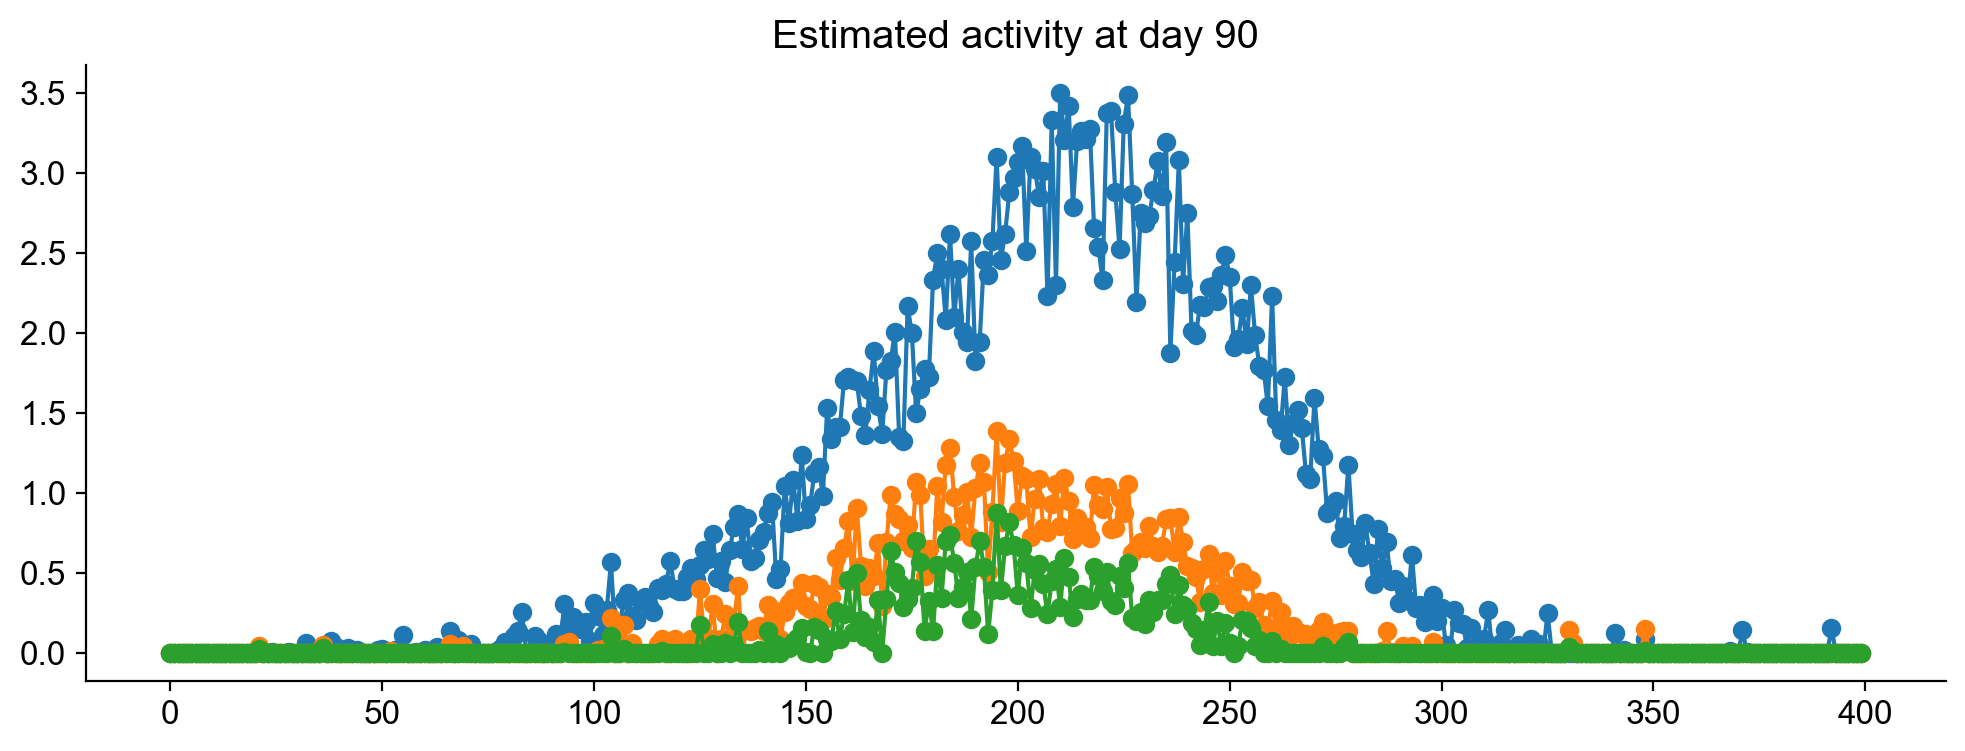

In [8]:
activity_1 = activity_1[0]
activity_2 = activity_2[0]
activity_3 = activity_3[0]

plt.figure(dpi=200, figsize=(12,4))
plt.plot(activity_1, marker='o', label="I scale = 0.3")
plt.plot(activity_2, marker='o', label="I scale = 0.6")
plt.plot(activity_3, marker='o', label="I scale = 0.9")
plt.title("Estimated activity at day 90") 

In [ ]:
# Plot drift magnitude vs assigned tuning width

fig, axs = plt.subplots(1, 3, figsize=(8, 3), dpi=200, sharex= True, sharey=True)
axs[0].scatter(net_inh_1.vars_ef, drift_mag_1[-1], alpha=0.7)
axs[0].set_title('I scale = 0.3')
axs[0].set_xlabel('vars_ef')
axs[0].set_ylabel('Drift magnitude')
axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[1].scatter(net_inh_2.vars_ef, drift_mag_2[-1], alpha=0.7)
axs[1].set_title('I scale = 0.6')
axs[1].set_xlabel('vars_ef')
axs[1].set_ylabel('Drift magnitude')

axs[2].scatter(net_inh_3.vars_ef, drift_mag_3[-1], alpha=0.7)
axs[2].set_title('I scale = 0.9')
axs[2].set_xlabel('vars_ef')
axs[2].set_ylabel('Drift magnitude')
fig.suptitle("Drift magnitude vs vars_ef")
fig.tight_layout()
